# 03 — EDA breve del ETL + Feature Engineering (P1 · entrega tardía)

**Etapa 3 — Vertex Insights.** Este notebook **no repite** el EDA exhaustivo de la Etapa 2 (`02_EDA_VERTEX.ipynb`). Su único objetivo es **mostrar, con gráficas de antes/después, qué cambió** tras el ETL y el feature engineering de P1:

- De una tabla **item-level con todos los estados** a una **tabla analítica a nivel orden** sobre el universo `delivered`.
- El **target** `entrega_tarde` y su tasa base.
- Las **features [t0]** construidas (días prometidos, distancia haversine, ratio de flete, tasa histórica del vendedor sin fuga, estacionalidad).
- La **resolución de nulos** (geo, dimensiones) y el **split temporal**.

> Entradas: `orders_consolidated.csv` (crudo consolidado) y `orders_p1_features.csv` (salida del pipeline `src/features/build_dataset.py`). Disciplina anti-leakage: D-21 / R-12.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

VERTEX = "/Users/amaury/henry/Proyecto_Final/vertex_files"
raw = pd.read_csv(f"{VERTEX}/orders_consolidated.csv")
fe = pd.read_csv(f"{VERTEX}/orders_p1_features.csv", parse_dates=["order_purchase_timestamp"])

# Carpeta donde se exportan las figuras de este EDA.
FIGS = Path("../reports/figures_eda_etapa3")
FIGS.mkdir(parents=True, exist_ok=True)

def guardar(nombre: str):
    """Exporta la figura activa a reports/figures_eda_etapa3/<nombre>.png."""
    plt.savefig(FIGS / f"{nombre}.png", dpi=150, bbox_inches="tight")

print(f"Crudo (item-level): {raw.shape[0]:,} filas x {raw.shape[1]} columnas")
print(f"Features (order-level): {fe.shape[0]:,} filas x {fe.shape[1]} columnas")
print(f"Figuras se exportarán a: {FIGS.resolve()}")

Crudo (item-level): 112,650 filas x 56 columnas
Features (order-level): 96,470 filas x 21 columnas
Figuras se exportarán a: /Users/amaury/Library/Mobile Documents/com~apple~CloudDocs/henry/Proyecto_Final/vertex-insights-olist-recommender/reports/figures_eda_etapa3


## 1. Antes/después del ETL: granularidad y universo

El crudo está a nivel **ítem** y contiene **todos los estados**. La tabla de P1 está a nivel **orden** y solo sobre `delivered` (las no entregadas se caracterizan aparte, D-20).

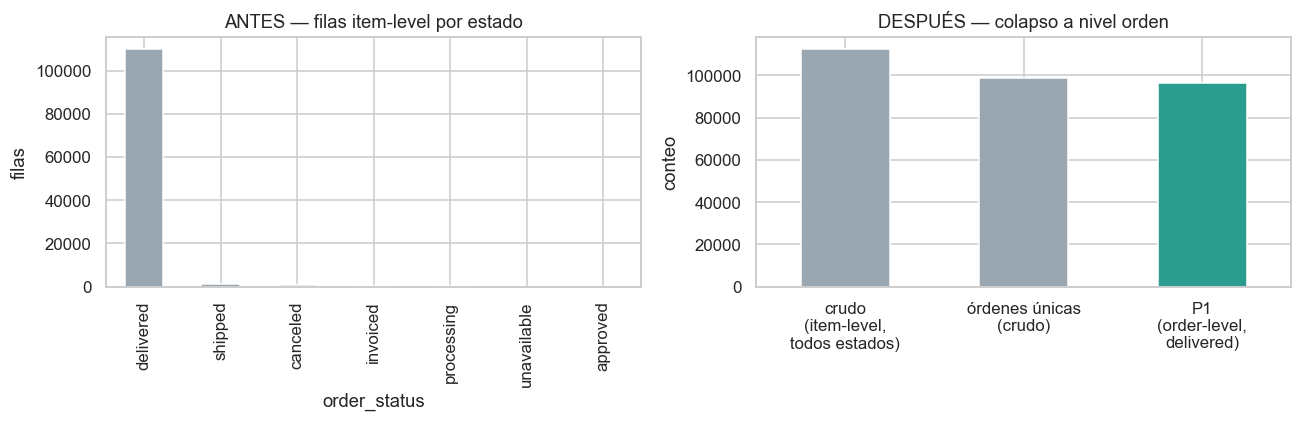

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

raw["order_status"].value_counts().plot(kind="bar", ax=axes[0], color="#9aa7b1")
axes[0].set_title("ANTES — filas item-level por estado")
axes[0].set_ylabel("filas"); axes[0].set_xlabel("order_status")

comp = pd.Series({
    "crudo\n(item-level,\ntodos estados)": raw.shape[0],
    "órdenes únicas\n(crudo)": raw["order_id"].nunique(),
    "P1\n(order-level,\ndelivered)": fe.shape[0],
})
comp.plot(kind="bar", ax=axes[1], color=["#9aa7b1", "#9aa7b1", "#2a9d8f"])
axes[1].set_title("DESPUÉS — colapso a nivel orden")
axes[1].set_ylabel("conteo"); axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout(); guardar("01_granularidad_universo"); plt.show()

## 2. Target `entrega_tarde` — tasa base

Desbalance sano (~8%). Es el complemento del KPI de negocio *tasa de entrega a tiempo* (D-19).

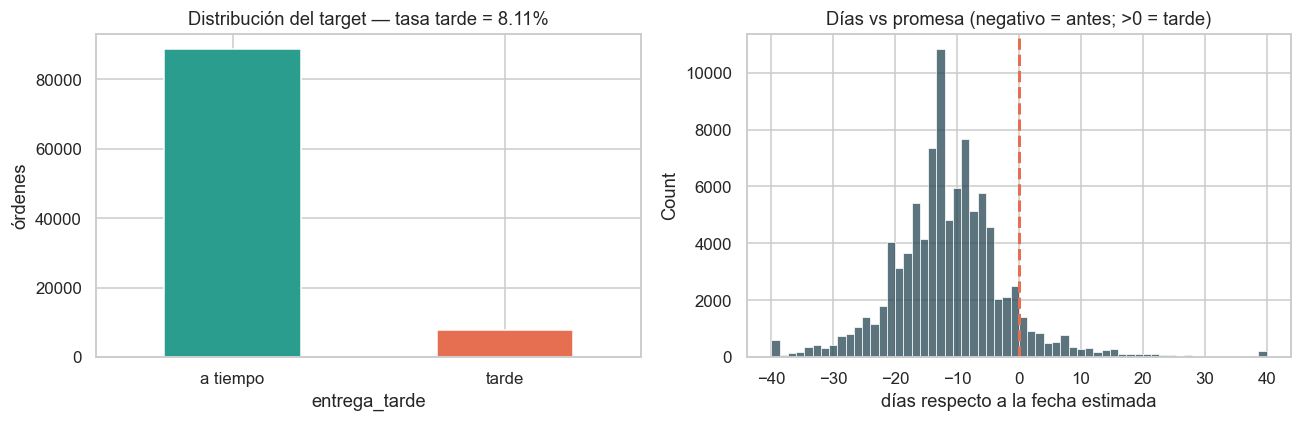

Colchón mediano de la promesa: -11.9 días


In [3]:
tasa = fe["entrega_tarde"].mean()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

fe["entrega_tarde"].map({0: "a tiempo", 1: "tarde"}).value_counts().plot(
    kind="bar", ax=axes[0], color=["#2a9d8f", "#e76f51"]
)
axes[0].set_title(f"Distribución del target — tasa tarde = {tasa*100:.2f}%")
axes[0].set_ylabel("órdenes"); axes[0].tick_params(axis="x", rotation=0)

sns.histplot(fe["dias_vs_promesa"].clip(-40, 40), bins=60, ax=axes[1], color="#264653")
axes[1].axvline(0, color="#e76f51", lw=2, ls="--")
axes[1].set_title("Días vs promesa (negativo = antes; >0 = tarde)")
axes[1].set_xlabel("días respecto a la fecha estimada")
plt.tight_layout(); guardar("02_target_entrega_tarde"); plt.show()
print(f"Colchón mediano de la promesa: {fe['dias_vs_promesa'].median():.1f} días")

## 3. Sanity check de negocio: el gradiente regional se conserva

Las features no deben romper los hallazgos del EDA. La tasa por estado del cliente debe seguir mostrando el contraste **Norte/Nordeste vs São Paulo**.

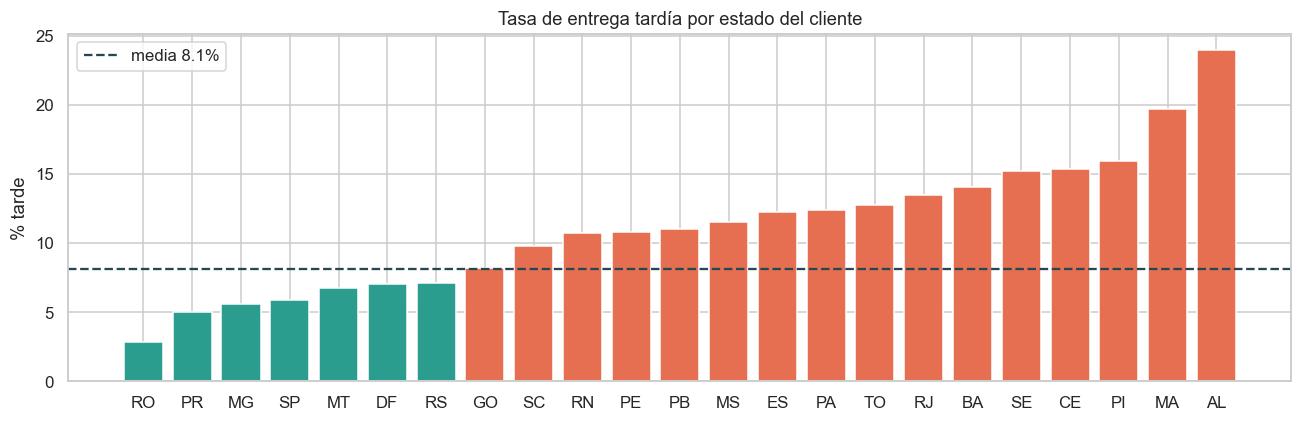

SP: 5.9%   |   AL: 23.9%  (≈4.1x)


In [4]:
g = (fe.groupby("customer_state")["entrega_tarde"]
       .agg(["mean", "count"]))
g = g[g["count"] > 200].sort_values("mean")

plt.figure(figsize=(12, 4))
colors = ["#e76f51" if v > tasa else "#2a9d8f" for v in g["mean"]]
plt.bar(g.index, g["mean"] * 100, color=colors)
plt.axhline(tasa * 100, color="#264653", ls="--", label=f"media {tasa*100:.1f}%")
plt.title("Tasa de entrega tardía por estado del cliente")
plt.ylabel("% tarde"); plt.legend(); plt.tight_layout()
guardar("03_gradiente_regional"); plt.show()
print(f"SP: {g.loc['SP','mean']*100:.1f}%   |   AL: {g.loc['AL','mean']*100:.1f}%  (≈{g.loc['AL','mean']/g.loc['SP','mean']:.1f}x)")

## 4. Features [t0] nuevas — distribuciones y poder de separación

Cuatro features construidas en esta etapa. La **tasa histórica del vendedor** se calcula *point-in-time* (solo órdenes anteriores), por eso es legítima.

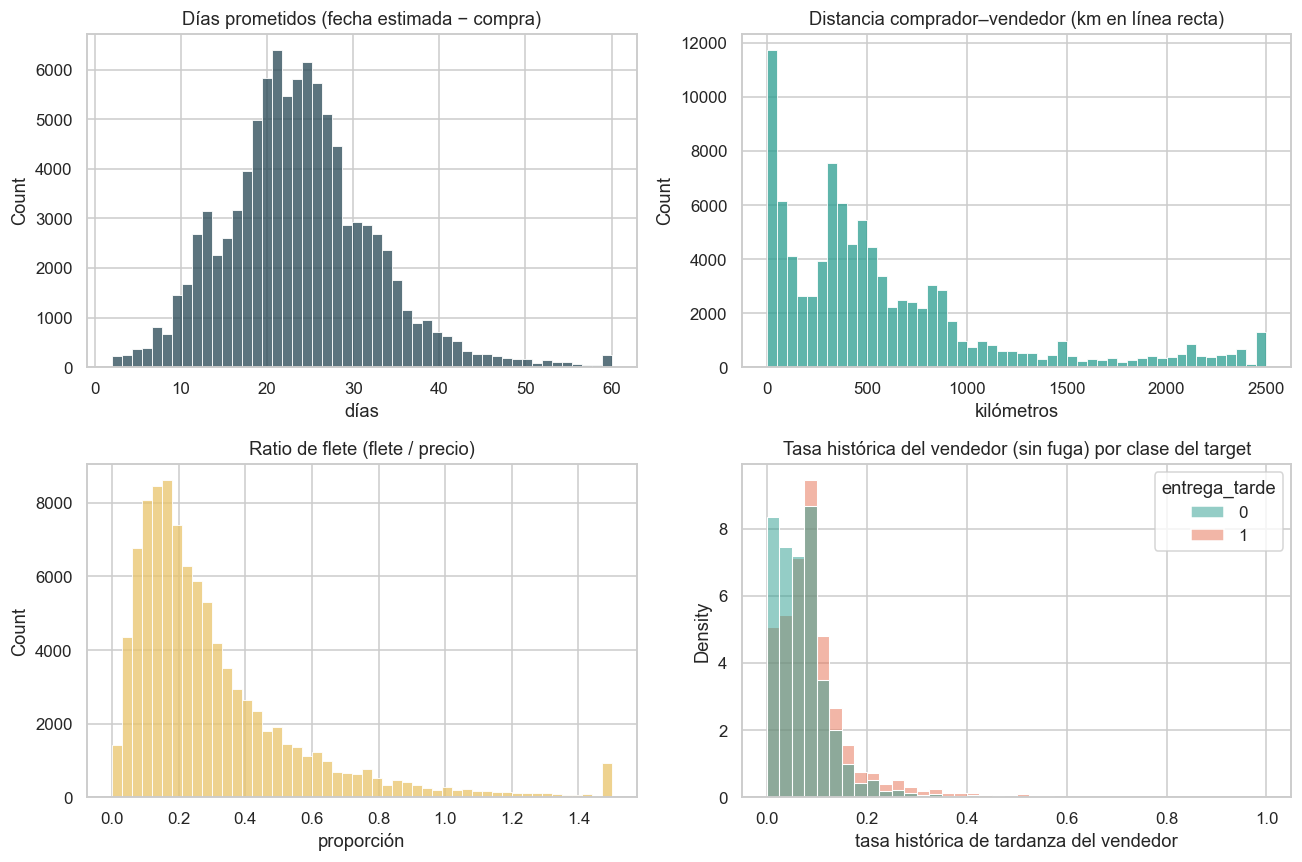

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(fe["dias_prometidos"].clip(0, 60), bins=50, ax=axes[0, 0], color="#264653")
axes[0, 0].set_title("Días prometidos (fecha estimada − compra)")
axes[0, 0].set_xlabel("días")

sns.histplot(fe["dist_haversine_km"].dropna().clip(0, 2500), bins=50, ax=axes[0, 1], color="#2a9d8f")
axes[0, 1].set_title("Distancia comprador–vendedor (km en línea recta)")
axes[0, 1].set_xlabel("kilómetros")

sns.histplot(fe["ratio_flete"].clip(0, 1.5), bins=50, ax=axes[1, 0], color="#e9c46a")
axes[1, 0].set_title("Ratio de flete (flete / precio)")
axes[1, 0].set_xlabel("proporción")

sns.histplot(data=fe, x="tasa_vendedor", hue="entrega_tarde", bins=40,
             ax=axes[1, 1], palette=["#2a9d8f", "#e76f51"], stat="density", common_norm=False)
axes[1, 1].set_title("Tasa histórica del vendedor (sin fuga) por clase del target")
axes[1, 1].set_xlabel("tasa histórica de tardanza del vendedor")
plt.tight_layout(); guardar("04_features_distribuciones"); plt.show()

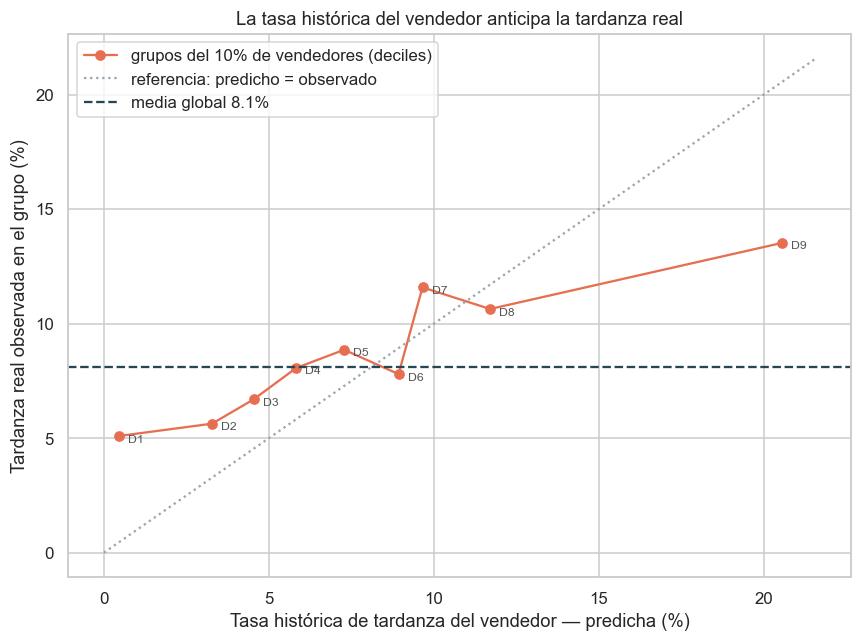

D1 = 10% de órdenes con menor tasa histórica del vendedor; D10 = el 10% con mayor tasa.
            tasa_hist_pct  tarde_obs_pct
decil_tasa                              
1                     0.5            5.1
2                     3.3            5.6
3                     4.5            6.7
4                     5.8            8.1
5                     7.3            8.9
6                     8.9            7.8
7                     9.7           11.6
8                    11.7           10.6
9                    20.5           13.5


In [6]:
# ¿La tasa histórica del vendedor anticipa la tardanza real? Se agrupan las órdenes
# en 10 grupos de igual tamaño (deciles) según su `tasa_vendedor` y, para cada grupo,
# se compara la tasa histórica (lo que la feature "predice") contra la tardanza real
# observada. Si la feature es informativa, ambos suben juntos (cerca de la diagonal).
fe["decil_tasa"] = pd.qcut(fe["tasa_vendedor"], 10, duplicates="drop", labels=False) + 1
cal = (fe.groupby("decil_tasa", observed=True)
         .agg(tasa_hist_pct=("tasa_vendedor", "mean"),
              tarde_obs_pct=("entrega_tarde", "mean"))) * 100

plt.figure(figsize=(8, 6))
plt.plot(cal["tasa_hist_pct"], cal["tarde_obs_pct"], marker="o", color="#e76f51",
         label="grupos del 10% de vendedores (deciles)")
lim = max(cal["tasa_hist_pct"].max(), cal["tarde_obs_pct"].max()) * 1.05
plt.plot([0, lim], [0, lim], ls=":", color="#9aa7b1", label="referencia: predicho = observado")
plt.axhline(tasa * 100, color="#264653", ls="--", label=f"media global {tasa*100:.1f}%")
for d, r in cal.iterrows():
    plt.annotate(f"D{int(d)}", (r["tasa_hist_pct"], r["tarde_obs_pct"]),
                 textcoords="offset points", xytext=(6, -4), fontsize=8, color="#555")
plt.title("La tasa histórica del vendedor anticipa la tardanza real")
plt.xlabel("Tasa histórica de tardanza del vendedor — predicha (%)")
plt.ylabel("Tardanza real observada en el grupo (%)")
plt.legend(); plt.tight_layout(); guardar("05_separacion_tasa_vendedor"); plt.show()
print("D1 = 10% de órdenes con menor tasa histórica del vendedor; D10 = el 10% con mayor tasa.")
print(cal.round(1))

## 5. Resolución de nulos (antes/después)

El ETL resuelve los huecos de dimensiones de producto y deja la geolocalización faltante para el imputador del pipeline (mediana en train).

> **Comparación justa (nivel orden).** Para que el "antes" sea comparable con el "después", el crudo se mira a **nivel orden** (primer ítem) y solo sobre `delivered`. La feature **distancia** se considera nula cuando falta la coordenada del **cliente _o_ del vendedor**; por eso su % de nulos es la **unión** de ambos huecos (~0.5%) y **no** significa que la geo del vendedor haya empeorado (la del vendedor por sí sola se mantiene en ~0.22%).


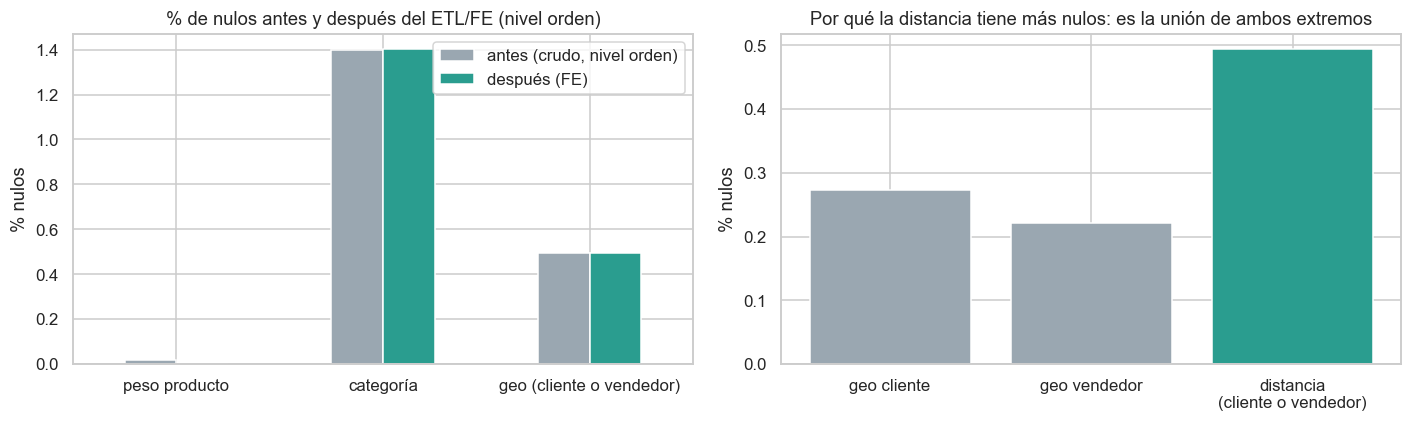

                          antes (crudo, nivel orden)  después (FE)
peso producto                                  0.017         0.000
categoría                                      1.400         1.400
geo (cliente o vendedor)                       0.493         0.493

Geo cliente: 0.27%  +  geo vendedor: 0.22%  ≈  distancia nula: 0.49%
La distancia es nula si falta CUALQUIERA de los dos extremos; no es un deterioro del vendedor.


In [7]:
# "Antes" comparable: crudo a NIVEL ORDEN (primer ítem) sobre el universo delivered.
raw_ord = (raw[raw["order_status"] == "delivered"]
           .sort_values(["order_id", "order_item_id"])
           .groupby("order_id").first())

geo_cli_antes = raw_ord["customer_lat"].isna().mean() * 100
geo_ven_antes = raw_ord["seller_lat"].isna().mean() * 100
geo_union_antes = (raw_ord["customer_lat"].isna() | raw_ord["seller_lat"].isna()).mean() * 100

antes = {
    "peso producto": raw_ord["product_weight_g"].isna().mean() * 100,
    "categoría": raw_ord["product_category_name_english"].isna().mean() * 100,
    "geo (cliente o vendedor)": geo_union_antes,
}
despues = {
    "peso producto": fe["peso_total_g"].isna().mean() * 100,
    "categoría": fe["categoria_principal"].isna().mean() * 100,
    "geo (cliente o vendedor)": fe["dist_haversine_km"].isna().mean() * 100,  # distancia
}
comp = pd.DataFrame({"antes (crudo, nivel orden)": antes, "después (FE)": despues})

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

comp.plot(kind="bar", ax=axes[0], color=["#9aa7b1", "#2a9d8f"])
axes[0].set_title("% de nulos antes y después del ETL/FE (nivel orden)")
axes[0].set_ylabel("% nulos"); axes[0].set_xlabel(""); axes[0].tick_params(axis="x", rotation=0)

# Desglose de la geo: el hueco de la distancia = unión de cliente y vendedor.
desglose = pd.Series({
    "geo cliente": geo_cli_antes,
    "geo vendedor": geo_ven_antes,
    "distancia\n(cliente o vendedor)": fe["dist_haversine_km"].isna().mean() * 100,
})
axes[1].bar(desglose.index, desglose.values, color=["#9aa7b1", "#9aa7b1", "#2a9d8f"])
axes[1].set_title("Por qué la distancia tiene más nulos: es la unión de ambos extremos")
axes[1].set_ylabel("% nulos"); axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout(); guardar("06_nulos_antes_despues"); plt.show()
print(comp.round(3))
print(f"\nGeo cliente: {geo_cli_antes:.2f}%  +  geo vendedor: {geo_ven_antes:.2f}%  ≈  distancia nula: {desglose.iloc[2]:.2f}%")
print("La distancia es nula si falta CUALQUIERA de los dos extremos; no es un deterioro del vendedor.")

## 6. Split temporal y régimen 2018 (R-14)

El corte es por **fecha de compra** (no aleatorio): train = pasado, val/test = futuro. Se inspecciona la tasa mensual para vigilar el régimen anómalo de finales de 2018.

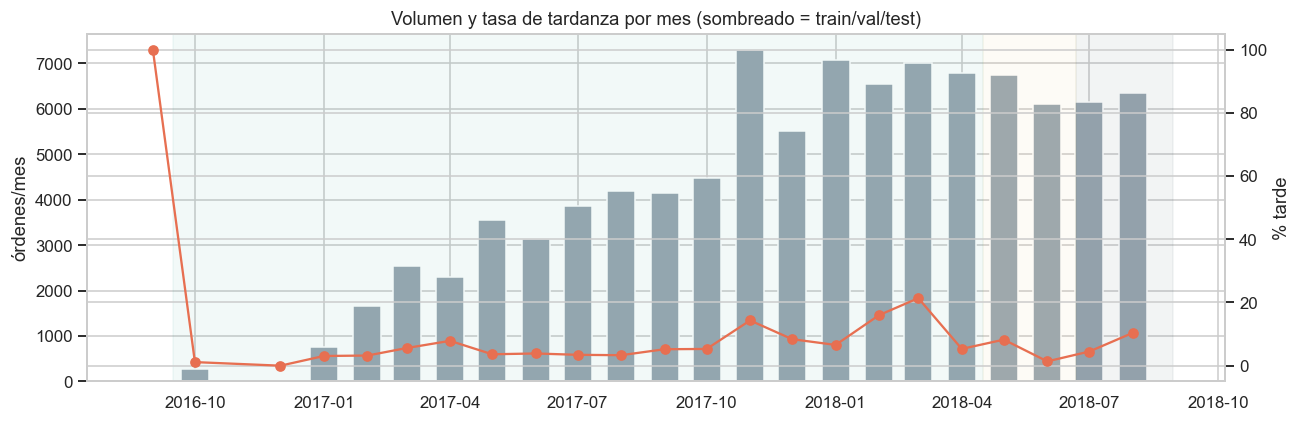

split
train    67529
test     14471
val      14470
Name: count, dtype: int64


In [8]:
fe["mes"] = fe["order_purchase_timestamp"].dt.to_period("M").dt.to_timestamp()
mensual = fe.groupby("mes").agg(vol=("entrega_tarde", "size"), tasa=("entrega_tarde", "mean"))

fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.bar(mensual.index, mensual["vol"], width=20, color="#9aa7b1", label="volumen")
ax1.set_ylabel("órdenes/mes")
ax2 = ax1.twinx()
ax2.plot(mensual.index, mensual["tasa"] * 100, color="#e76f51", marker="o", label="% tarde")
ax2.set_ylabel("% tarde")

for etiqueta, sub in fe.groupby("split"):
    ax1.axvspan(sub["order_purchase_timestamp"].min(), sub["order_purchase_timestamp"].max(),
                alpha=0.06, color={"train": "#2a9d8f", "val": "#e9c46a", "test": "#264653"}[etiqueta])
ax1.set_title("Volumen y tasa de tardanza por mes (sombreado = train/val/test)")
plt.tight_layout(); guardar("07_split_temporal_regimen2018"); plt.show()
print(fe["split"].value_counts())

## 7. Resumen de cambios

| Dimensión | Antes (crudo) | Después (P1) |
|---|---|---|
| Granularidad | ítem | **orden** |
| Universo | todos los estados | **`delivered`** |
| Filas | 112,650 | **96,470** |
| Target | — | **`entrega_tarde`** (8.11%) |
| Features [t0] | — | días prometidos, dist. haversine, ratio flete, peso/volumen, categoría, estacionalidad, `mismo_estado`, **tasa del vendedor sin fuga** |
| Leakage | columnas [POST] mezcladas | **[POST] excluidas** (reviews, entrega real) |
| Geo nula | lat/lng faltante | transformada en distancia + imputación en pipeline |
| Split | — | **temporal 70/15/15** por fecha de compra |

El sanity check de negocio se mantiene (gradiente regional SP≈6% vs AL≈24%) y la `tasa_vendedor` muestra poder de separación legítimo. La tabla `orders_p1_features.csv` y el pipeline `artifacts/pipeline_p1.joblib` quedan listos para el modelado (Etapa 4).